./Data\d_123.csv
file processed: ./Data\d_123.csv

Missing values per column:
Tick        0
Throttle    0
Speed       0
Current     0
Voltage     0
Time        0
TimePlot    0
dtype: int64

Total energy consumed: 0.016142620613271808 kWh

Efficiency: 49.56 km/kWh


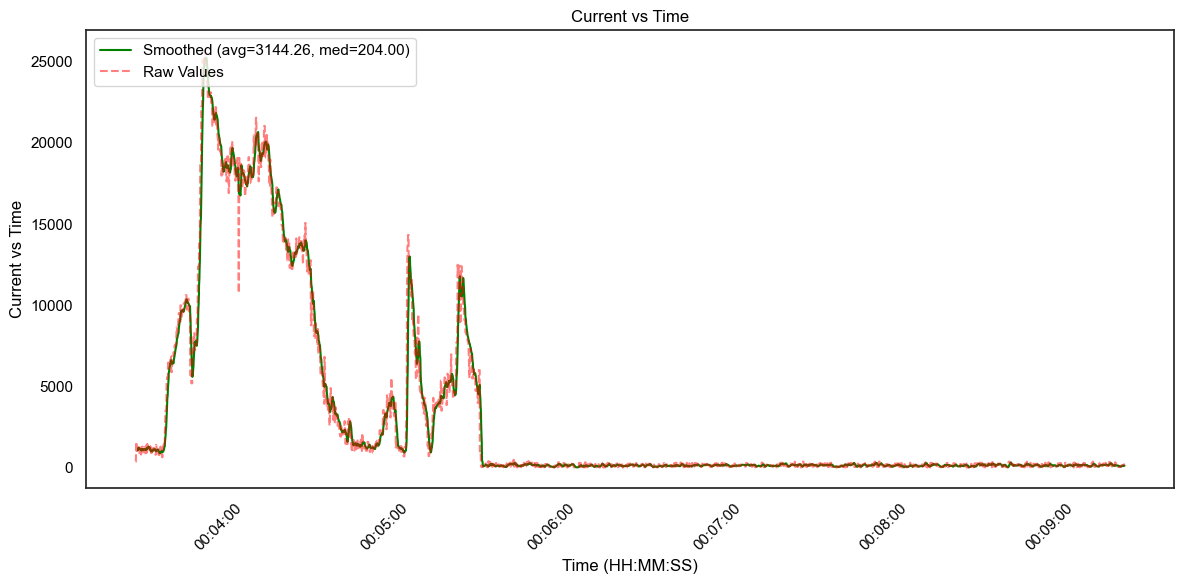

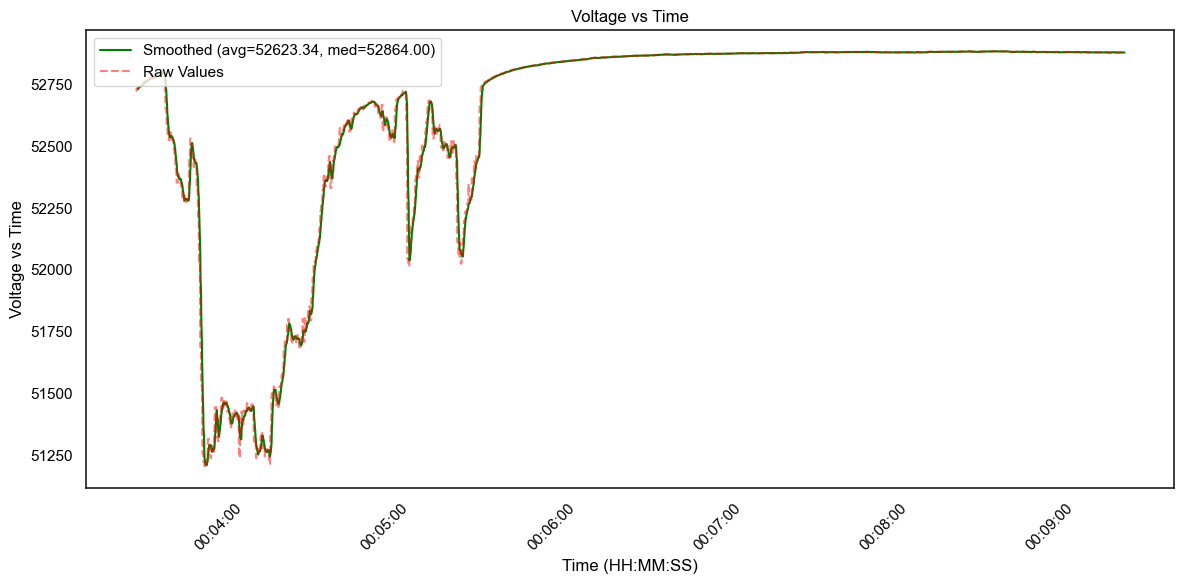

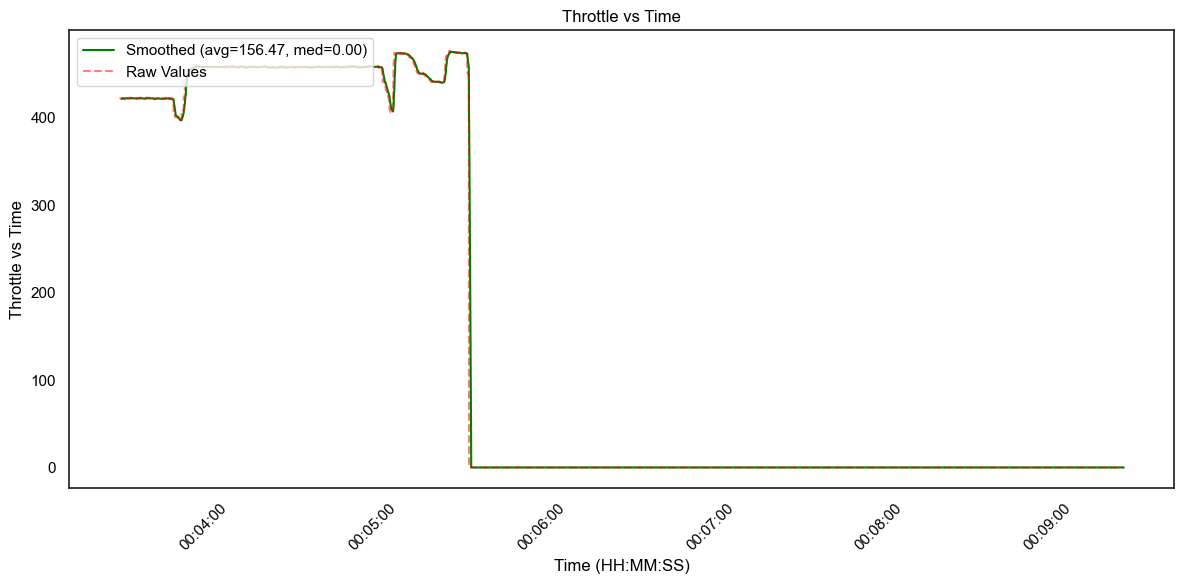

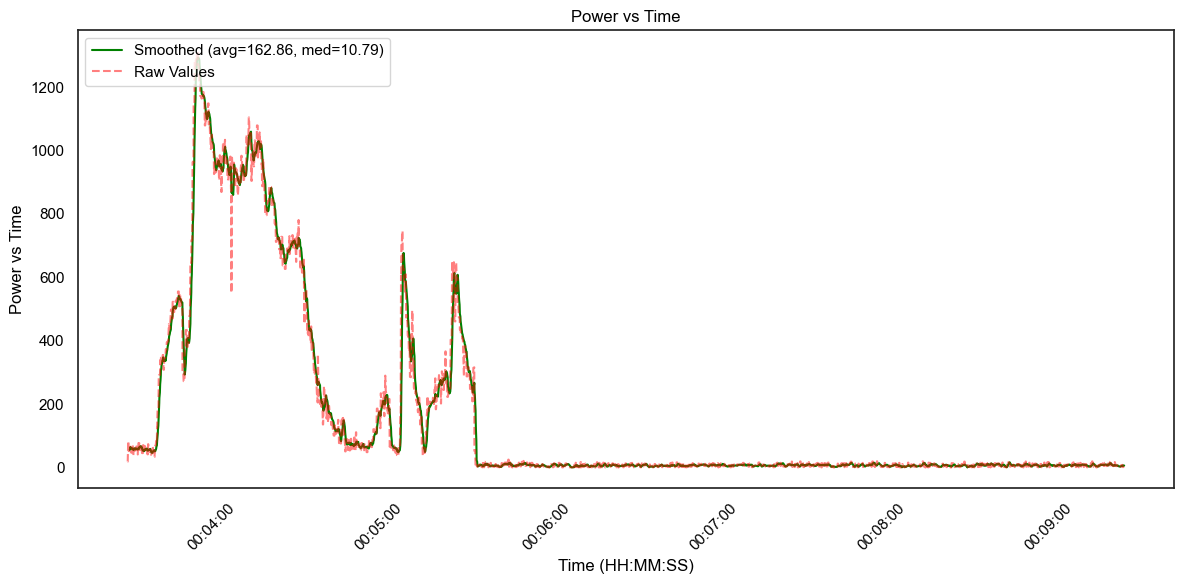

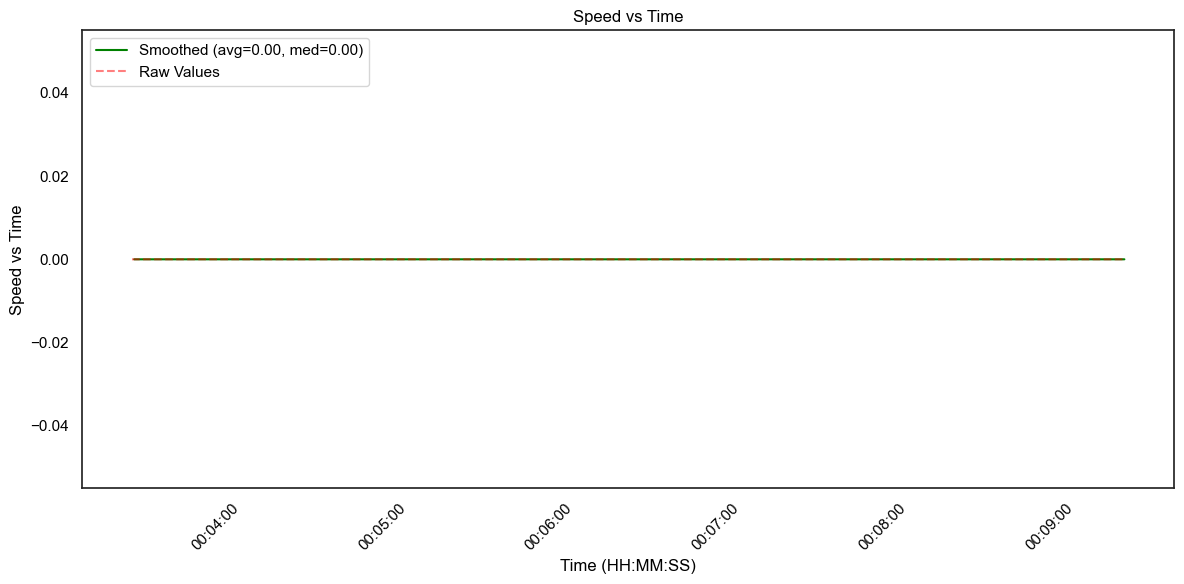

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
import matplotlib.dates as mdates
import os
import NulRemover

sns.set(style='white')  # light background
data_folder = './Data'
num = 123
file = f'd_{num}.csv'
path = os.path.join(data_folder, file)
print(path)
NulRemover.remove_nuls(path)  # Clean the file from null characters
print(f"file processed: {path}")
delimiter = ','
distance = 0.8 #Distance in km, used for efficiency calculation
Ticks = True  # Set to False if did not correct ticks
start_throttle = 10  # Minimum throttle to start plotting
throttle_start_flag = False
plot_outliers = False  # Set to False to not plot outliers



start_ms = 210000

# Load and clean data
# def clean_cell(cell):
#     # Keep only alphanumeric and spaces
#     return float(re.sub(r'[^a-zA-Z0-9]', '', str(cell)))
# def last_digits(cell, n=5):
#     match = re.search(r'(\d{%d})\D*$' % n, str(cell))
#     return match.group(1) if match else ''
#data = pd.read_csv(path, converters={'Ticks': lambda x: last_digits(x, 5)})
#data['Tick'] = (data['Tick'].apply(clean_cell))
data = pd.read_csv(path, delimiter = delimiter)
data.columns = data.columns.str.strip()

# Remove rows before the first throttle > start_throttle
if throttle_start_flag:
    start_throttle_index = data[data['Throttle'] >= start_throttle].index.min()
    data = data.iloc[start_throttle_index:]

# Convert Tick to time
if Ticks:
    data['Tick'] = data['Tick'].astype(int)  # Ensure Tick is int
    data['Time'] = pd.to_timedelta(data['Tick'], unit='ms')
    data['TimePlot'] = pd.Timestamp("2023-01-01") + data['Time']
else:
    data['TimePlot'] = range(len(data))

if start_ms != 0:
    data = data[data['Tick'] >= start_ms]
    #data = data.iloc[index:]
# Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())

#Add power calculation
if 'Current' in data.columns and 'Voltage' in data.columns:
    data['Power'] = (data['Current'] / 1e3) * (data['Voltage']/1e3)

#Add total energy calculation
if 'Power' in data.columns:
    energy_joules = np.trapz(data['Power'], x = data['Tick'] / 1e3)
    energy_kWh = energy_joules / 3600000  # Convert from J to kWh
    print(f"\nTotal energy consumed: {energy_kWh} kWh")

if distance !=1:
    #Calculate efficiency
    efficiency = distance/energy_kWh  # kWh per meter
    print(f"\nEfficiency: {efficiency:.2f} km/kWh")



# Columns to visualize
#columns_to_plot = ['Throttle', 'Speed', 'Current', 'Voltage', 'Speed1']
columns_to_plot = ['Current', 'Voltage','Throttle','Power', 'Speed']
#data.dropna(subset=['TimePlot'] + columns_to_plot, inplace=True)

# Plot each column
for col in columns_to_plot:
    if col in data.columns:
        x = data['TimePlot']
        y = data[col]
        y_smooth = y.rolling(window=10).mean()

        # Stats
        avg = y.mean()
        med = y.median()

        # Outliers (Z-score method)
        z_scores = zscore(y)
        outliers = np.abs(z_scores) > 2

        # Start plotting
        fig, ax = plt.subplots(figsize=(12, 6))

        #Use numpy arrays for plotting with only first dimension (this is weird)
    

        # Smoothed line
        ax.plot(x, y_smooth, color='green', label=f'Smoothed (avg={avg:.2f}, med={med:.2f})')

        # Raw dashed line
        ax.plot(x,y, linestyle='--', color='red', alpha=0.5, label='Raw Values')

        # Outliers as blue dots
        if plot_outliers:
            ax.scatter(x[outliers], y[outliers], color='blue', label='Outliers')

        # Labeling and formatting
        ax.set_xlabel("Time (HH:MM:SS)", color='black')
        ax.set_ylabel(f"{col} vs Time", color='black')
        ax.set_title(f"{col} vs Time", color='black')
        ax.tick_params(axis='x', colors='black', rotation=45)
        ax.tick_params(axis='y', colors='black')

        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

        # Legend in black
        legend = ax.legend(loc='upper left')
        for text in legend.get_texts():
            text.set_color('black')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in dataset.")


In [23]:
#Overlay power consumption of a second run (INCOMPLETE)

sns.set(style='white')  # light background
date = "250817"
time = "131122"
data_folder = f'./{date}/'
file = f'{date}-{time}.csv'
path = os.path.join(data_folder, file)
delimiter = ','
skiprows = 27
distance = 2.4 #Distance in km, used for efficiency calculation
Ticks = False  # Set to False if did not correct ticks
start_throttle = 0.1  # Minimum throttle to start plotting
throttle_start_flag = False
plot_outliers = False  # Set to False to not plot outliers
# Load and clean data
# def clean_cell(cell):
#     # Keep only alphanumeric and spaces
#     return float(re.sub(r'[^a-zA-Z0-9]', '', str(cell)))
# def last_digits(cell, n=5):
#     match = re.search(r'(\d{%d})\D*$' % n, str(cell))
#     return match.group(1) if match else ''
#data_2 = pd.read_csv(path, converters={'Ticks': lambda x: last_digits(x, 5)})
#data_2['Tick'] = (data_2['Tick'].apply(clean_cell))
data_2 = pd.read_csv(path, delimiter = delimiter, skiprows = skiprows)
data_2.columns = data_2.columns.str.strip()

# Remove rows before the first throttle > start_throttle
if throttle_start_flag:
    start_throttle_index = data_2[data_2['Throttle'] >= start_throttle].index.min()
    data_2 = data_2.iloc[start_throttle_index:]

# Convert Tick to time
if Ticks:
    data_2['Tick'] = data_2['Tick'].astype(int)  # Ensure Tick is int
    data_2['Time'] = pd.to_timedelta(data_2['Tick'], unit='ms')
    data_2['TimePlot'] = pd.Timestamp("2023-01-01") + data_2['Time']
else:
    data_2['TimePlot'] = range(len(data_2))

# Convert NO to milliseconds
if 'NO.' in data_2.columns:
    data_2['milliseconds'] = data_2['NO.'] * 20

#Convert milliseconds to time
if 'milliseconds' in data_2.columns:
    data_2['Time'] = pd.to_timedelta(data_2['milliseconds'], unit='ms')
    data_2['TimePlot'] = pd.Timestamp("2023-01-01") + data_2['Time']

# Check for missing values
print("\nMissing values per column:")
print(data_2.isnull().sum())

#Convert to actual numbers
data_2['A'] = data_2['A'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
data_2['V'] = data_2['V'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)

#Add power calculation
if 'A' in data_2.columns and 'V' in data_2.columns:
    data_2['Power'] = (data_2['A']) * (data_2['V'])

#Add total energy calculation
if 'Power' in data_2.columns:
    energy_joules = np.trapz(data_2['Power'], x = data_2['milliseconds'] / 1e3)
    energy_kWh = energy_joules / 3600000  # Convert from J to kWh
    print(f"\nTotal energy consumed: {energy_kWh} kWh")

if distance !=1:
    #Calculate efficiency
    efficiency = distance/energy_kWh  # kWh per meter
    print(f"\nEfficiency: {efficiency:.2f} km/kWh")



# Columns to visualize
#columns_to_plot = ['Throttle', 'Speed', 'Current', 'Voltage', 'Speed1']
columns_to_plot = ['A','V','Power']
#data_2.dropna(subset=['TimePlot'] + columns_to_plot, inplace=True)

# Plot each column
for col in columns_to_plot:
    if col in data_2.columns:
        x_1 = data['TimePlot']
        y_1 = data[col]
        y_1_smooth = y_1.rolling(window=10).mean()
        x_2 = data_2['TimePlot']
        y_2 = data_2[col]
        y_2_smooth = y_2.rolling(window=10).mean()

        # Stats
        avg = y.mean()
        med = y.median()

        # Outliers (Z-score method)
        z_scores = zscore(y)
        outliers = np.abs(z_scores) > 2

        # Start plotting
        fig, ax = plt.subplots(figsize=(12, 6))

        #Use numpy arrays for plotting with only first dimension (this is weird)
    

        # Smoothed line
        ax.plot(x_1, y_1_smooth, color='green', label=f'Run 1')
        ax.plot(x_2, y_2_smooth, color='orange', label=f'Run 2')
        # Labeling and formatting
        ax.set_xlabel("Time (HH:MM:SS)", color='black')
        ax.set_ylabel(f"{col} vs Time", color='black')
        ax.set_title(f"{col} vs Time", color='black')
        ax.tick_params(axis='x', colors='black', rotation=45)
        ax.tick_params(axis='y', colors='black')

        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

        # Legend in black
        legend = ax.legend(loc='upper left')
        for text in legend.get_texts():
            text.set_color('black')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in dataset.")


Missing values per column:
NO.             0
Time            0
ms              0
A               0
V               0
C               0
A1234567890     0
ALP1-4          0
AO1234          0
TimePlot        0
milliseconds    0
dtype: int64

Total energy consumed: 0.03492905695222222 kWh

Efficiency: 68.71 km/kWh


KeyError: 'A'